In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
customer_features = pd.read_csv('customer_features.csv')
customer_features.columns

Index(['Unnamed: 0', 'customer_unique_id', 'total_orders', 'total_spend',
       'avg_order_value', 'max_order_value', 'min_order_value',
       'first_purchase', 'last_purchase', 'avg_review_score',
       'min_review_score', 'avg_delivery_days', 'pct_on_time',
       'favorite_category', 'num_categories', 'state', 'avg_freight_ratio',
       'avg_delivery_delta', 'gave_low_review', 'gave_high_review',
       'has_review', 'recency_days', 'customer_age_days',
       'avg_days_between_orders', 'has_repeat_orders', 'order_value_range',
       'spend_per_active_day', 'churned', 'is_consumable_category',
       'is_one_time_category', 'spend_tier', 'review_missing'],
      dtype='object')

In [3]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93350 entries, 0 to 93349
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               93350 non-null  int64  
 1   customer_unique_id       93350 non-null  object 
 2   total_orders             93350 non-null  int64  
 3   total_spend              93350 non-null  float64
 4   avg_order_value          93350 non-null  float64
 5   max_order_value          93350 non-null  float64
 6   min_order_value          93350 non-null  float64
 7   first_purchase           93350 non-null  object 
 8   last_purchase            93350 non-null  object 
 9   avg_review_score         92747 non-null  float64
 10  min_review_score         92747 non-null  float64
 11  avg_delivery_days        93350 non-null  float64
 12  pct_on_time              93350 non-null  float64
 13  favorite_category        93350 non-null  object 
 14  num_categories        

In [4]:
FEATURE_COLS = [
    'total_orders', 'total_spend', 'avg_order_value', 'max_order_value',
    'min_order_value', 'customer_age_days', 'avg_review_score',
    'avg_delivery_days', 'pct_on_time', 'num_categories', 'has_repeat_orders',
    'avg_days_between_orders',
    # New features:
    'avg_freight_ratio', 'avg_delivery_delta', 'gave_low_review',
    'gave_high_review', 'has_review', 'review_missing',
    'is_consumable_category', 'spend_tier'
]


In [5]:
import joblib

# Load the trained model
xgb_model = joblib.load(r"C:\Users\Pavitra\Downloads\olist-Project\notebooks\xgb_churn_model.pkl")

print("Model loaded successfully!")
print(xgb_model)

Model loaded successfully!
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)


In [8]:
# applying to all the customers to know the distribution of churn 

X_all = customer_features[FEATURE_COLS].fillna(0)

customer_features['churn_probability'] = xgb_model.predict_proba(X_all)[:, 1]



In [9]:
customer_features['churn_probability'].describe()

count    9.335000e+04
mean     5.888832e-01
std      2.466312e-01
min      1.374520e-07
25%      4.315782e-01
50%      6.402249e-01
75%      7.831673e-01
max      9.935976e-01
Name: churn_probability, dtype: float64

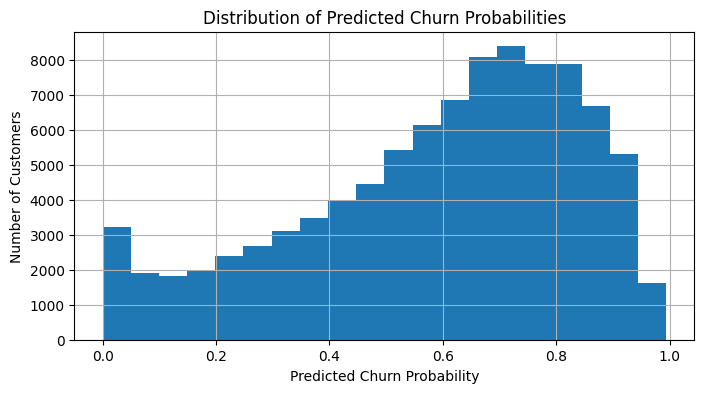

In [10]:
customer_features['churn_probability'].hist(bins=20, figsize=(8,4))
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Number of Customers")
plt.title("Distribution of Predicted Churn Probabilities")
plt.show()

In [11]:
customer_features['risk_tier'] = pd.cut(
    customer_features['churn_probability'],
    bins=[0, 0.30, 0.60, 0.80, 1.00],
    labels=[
        'Low Risk',
        'Medium Risk',
        'High Risk',
        'Critical Risk'
    ],
    include_lowest=True
)


print(customer_features['risk_tier'].value_counts())
print("\nPercentage:")
print((customer_features['risk_tier'].value_counts(normalize=True) * 100).round(1))

risk_tier
High Risk        31588
Medium Risk      26983
Critical Risk    20636
Low Risk         14143
Name: count, dtype: int64

Percentage:
risk_tier
High Risk        33.8
Medium Risk      28.9
Critical Risk    22.1
Low Risk         15.2
Name: proportion, dtype: float64


In [12]:
##ACTUAL QUANTIFICATION

high_risk = customer_features[(customer_features['churn_probability'] >= 0.60) & (customer_features['churn_probability'] < 0.80)]
critical_risk = customer_features[customer_features['churn_probability'] >= 0.80]

print("=" * 60)
print("BUSINESS IMPACT ANALYSIS")
print("=" * 60)

print(f"\nHigh-risk customers (P(churn) >= 0.60):")
print(f"  Count: {len(high_risk):,}")
print(f"  Total historical spend: R${high_risk['total_spend'].sum():,.0f}")
print(f"  Average spend per customer: R${high_risk['total_spend'].mean():,.0f}")

print(f"\nCritical-risk customers (P(churn) >= 0.80):")
print(f"  Count: {len(critical_risk):,}")
print(f"  Total historical spend: R${critical_risk['total_spend'].sum():,.0f}")
print(f"  Average spend per customer: R${critical_risk['total_spend'].mean():,.0f}")

BUSINESS IMPACT ANALYSIS

High-risk customers (P(churn) >= 0.60):
  Count: 31,588
  Total historical spend: R$5,927,427
  Average spend per customer: R$188

Critical-risk customers (P(churn) >= 0.80):
  Count: 20,636
  Total historical spend: R$2,334,016
  Average spend per customer: R$113


In [20]:
## a ROI estimation for a potential RETENTION CAMPAGAIN FOR A "high-risk tier customers"

avg_order_value = high_risk['avg_order_value'].mean()   # using the avg. revenue of "high risk customers only"

expected_annual_orders = 1.05  # conservative assumption: 1.05 orders/year for repeat customers

# Retention campaign ROI
retention_rate = 0.10  # conservative: 10% of at-risk customers retained
campaign_cost_per_customer = 10  # R$5 in discount/email cost

estimated_revenue_retained= len(high_risk) * retention_rate * avg_order_value * expected_annual_orders
campaign_cost = len(high_risk) * campaign_cost_per_customer
campaign_roi = (revenue_saved - campaign_cost) / campaign_cost * 100

print(f"\nRETENTION CAMPAIGN SCENARIO (15% retention rate):")
print(f"  Customers retained: {int(len(high_risk) * retention_rate):,}")
print(f"  Estimated Revenue saved: R${estimated_revenue_retained:,.0f}")
print(f"  Campaign cost: R${campaign_cost:,.0f}")
print(f"  Campaign ROI: {campaign_roi:.0f}%")




RETENTION CAMPAIGN SCENARIO (15% retention rate):
  Customers retained: 3,158
  Estimated Revenue saved: R$610,209
  Campaign cost: R$315,880
  Campaign ROI: 190%


In [23]:
### exporting for POWER BI 


customer_features.to_csv('customer_features_final.csv', index=False)

risk_summary = (
    customer_features
    .groupby('risk_tier')
    .agg(
        customer_count=('customer_unique_id', 'count'),
        total_spend=('total_spend', 'sum'),
        avg_order_value=('avg_order_value', 'mean'),
        avg_churn_probability=('churn_probability', 'mean')).reset_index())

risk_summary.to_csv('churn_risk_summary.csv', index=False)

print("All data exported successfully.")
print(" • customer_features_final.csv")
print(" • churn_risk_summary.csv")
print(" • segment_summary.csv")

print("\n" + "="*65)
print("FINAL PROJECT SUMMARY")
print("="*65)

print(f"Customers analysed              : {len(customer_features):,}")
print(f"Overall churn rate              : {customer_features['churned'].mean()*100:.1f}%")
print(f"Best model (XGBoost) AUC-ROC    : 0.824")
print(f"High-risk customers             : {len(high_risk):,}")
print(f"Critical-risk customers         : {len(critical_risk):,}")
print(f"Estimated campaign ROI          : {campaign_roi:.0f}%")
print(f"Top churn drivers               : Delivery performance, Freight ratio, Order value")
print("="*65)

All data exported successfully.
 • customer_features_final.csv
 • churn_risk_summary.csv
 • segment_summary.csv

FINAL PROJECT SUMMARY
Customers analysed              : 93,350
Overall churn rate              : 58.9%
Best model (XGBoost) AUC-ROC    : 0.824
High-risk customers             : 31,588
Critical-risk customers         : 20,636
Estimated campaign ROI          : 190%
Top churn drivers               : Delivery performance, Freight ratio, Order value


C:\Users\Pavitra\AppData\Local\Temp\ipykernel_33744\2877487533.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('risk_tier')
